# Handson 6 & 7 : Analyzing a simulation of surface convection

#### In this handson we will analyze a simulation of a surface layer of a star. The equations of magnetohydrodynamics are solved, together with equation of state and radiative transfer equation, to produce a box with values of various physical parameters. 

#### Today we will visualize these parameters and calculate some quantities 

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
atmos = np.load("/home/milic/data/scratch/exercise_63000.npy")

In [3]:
atmos.shape

(6, 512, 512, 480)

#### The dimensions are 6, 512, 512, 480. First number denotes the number of physical parameters I stored: 
0 - temperature 

1 - gas pressure 

2 - internal energy 

3 - vx

4 - vy 

5 - vz

#### Next three dimensions are x,y,z. 

#### For practice, plot the variation of temperature with depth for one value of x and y. 

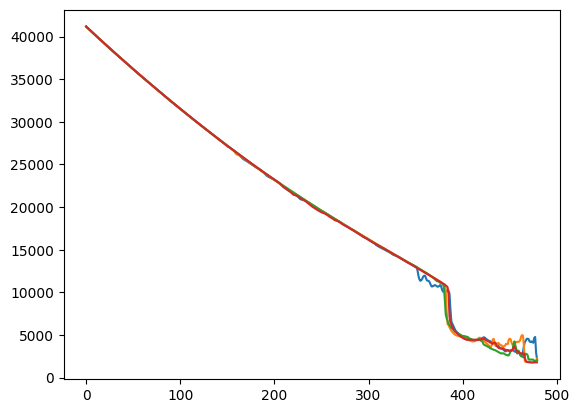

In [4]:
plt.plot(atmos[0,123,321,:])
plt.plot(atmos[0,213,401,:])
plt.plot(atmos[0,59,311,:])
plt.plot(atmos[0,421,256,:])

This is not temperature vs the depth index, z-spacing of the simulation is 16 km and x and y are 48 km. So: 

In [5]:
NX, NY, NZ = atmos[0].shape
x = np.arange(NX) * 48.0
y = np.arange(NY) * 48.0
z = np.arange(NZ) * 16.0

Text(0, 0.5, 'T [K]')

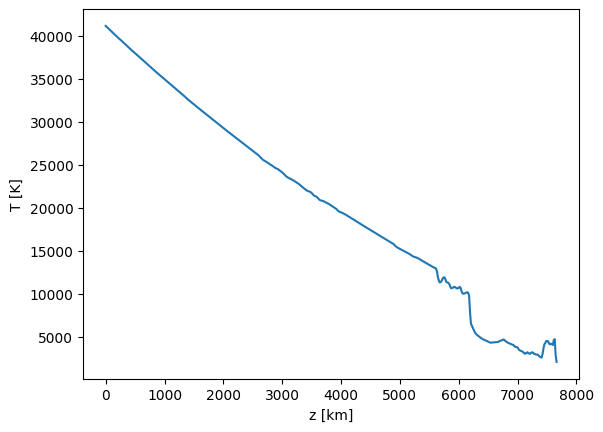

In [6]:
plt.plot(z,atmos[0,123,321,:])
plt.xlabel("z [km]")
plt.ylabel("T [K]")

#### To learn a bit more let's plot the temperature averaged over x and y: 

In [7]:
mean_atmos = np.mean(atmos, axis=(1,2))

Text(0, 0.5, 'T [K]')

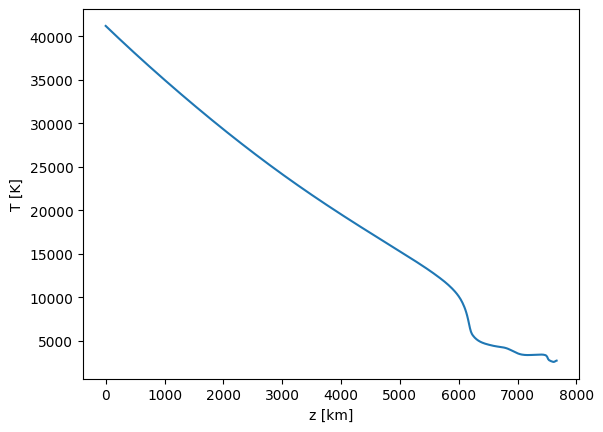

In [8]:
plt.plot(z,mean_atmos[0,:])
plt.xlabel("z [km]")
plt.ylabel("T [K]")

### Answer the following questions (material for the class): 

### 1) Why is temperature monotonically decreasing? Did you expect that? 

### 2) Why does it drop so rapidly around 60000 km? 

### 3) How would you define the Solar surface from this plot? 

### 4) How can you track the temperature variation in all three dimensions? 

### 5) Estimate the effective temperature of this "star" ? 

### New: We are going to find the depth index where the gradient of the temperature with height is the highest. 
### We will call that : the surface 

Text(0, 0.5, 'T [K]')

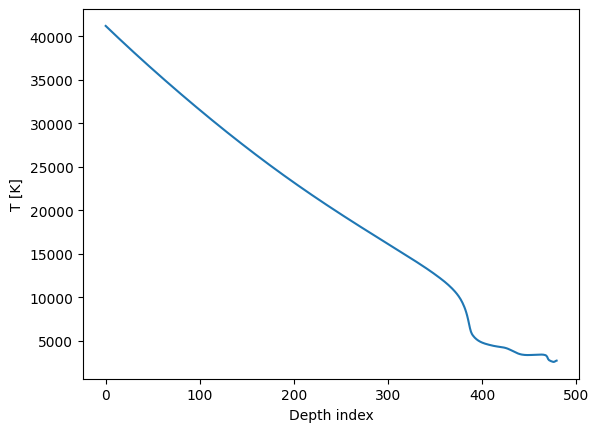

In [9]:
plt.plot(mean_atmos[0,:])
plt.xlabel("Depth index")
plt.ylabel("T [K]")

(380.0, 390.0)

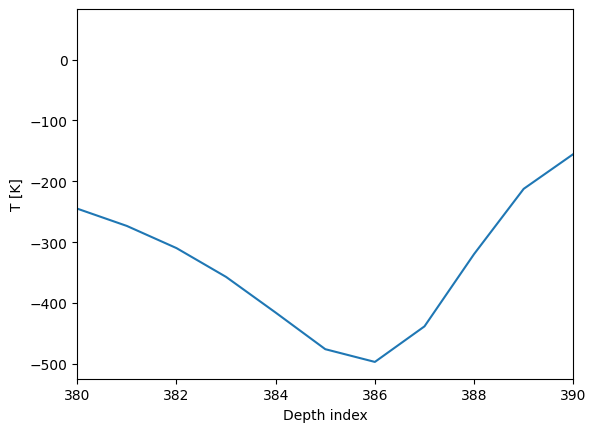

In [10]:
plt.plot(np.gradient(mean_atmos[0,:]))
plt.xlabel("Depth index")
plt.ylabel("T [K]")
plt.xlim([380,390])

In [11]:
# Offset the height according to the stellar surface 

z -= z[386]

## According to the approach we agreed on, the inflection point for the T(z) is at depth index 386!

#### But look at the approach below (Done at Handson #7)

## 2D plots of physical quantities at different heights (z= const): 

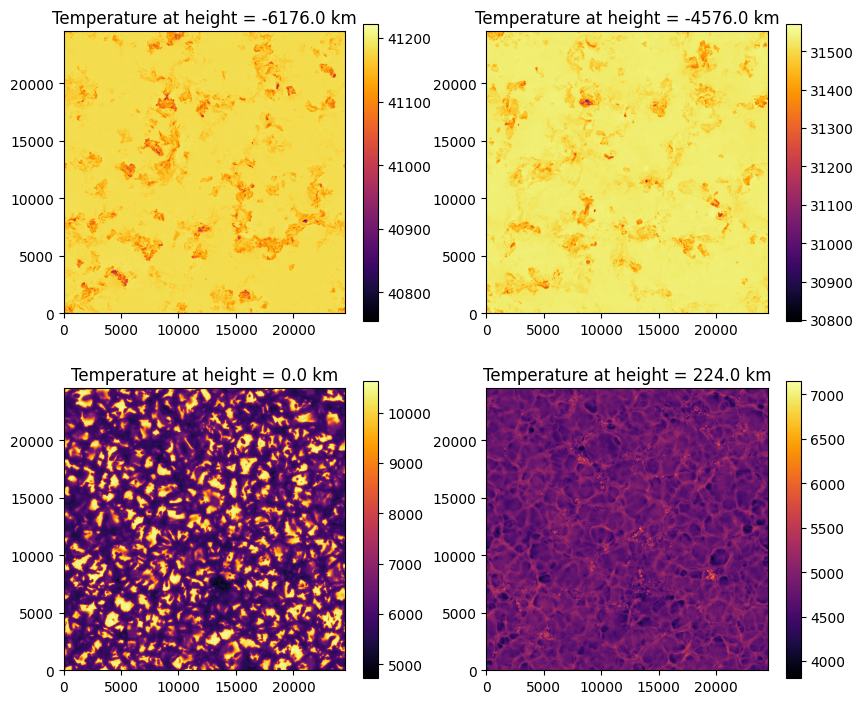

In [13]:
# Temperature:

heights = [0, 100, 386, 400]
plt.figure(figsize=[10,8.5]) 
for i in range(0,4):
    plt.subplot(2,2,i+1)
    plt.imshow(atmos[0,:,:,heights[i]].T, origin='lower', cmap = 'inferno', extent = [x[0],x[-1],y[0],y[-1]])
    plt.title("Temperature at height = "+str(z[heights[i]])+ " km")
    plt.colorbar()

## 5a) What looks the most like the surface? 

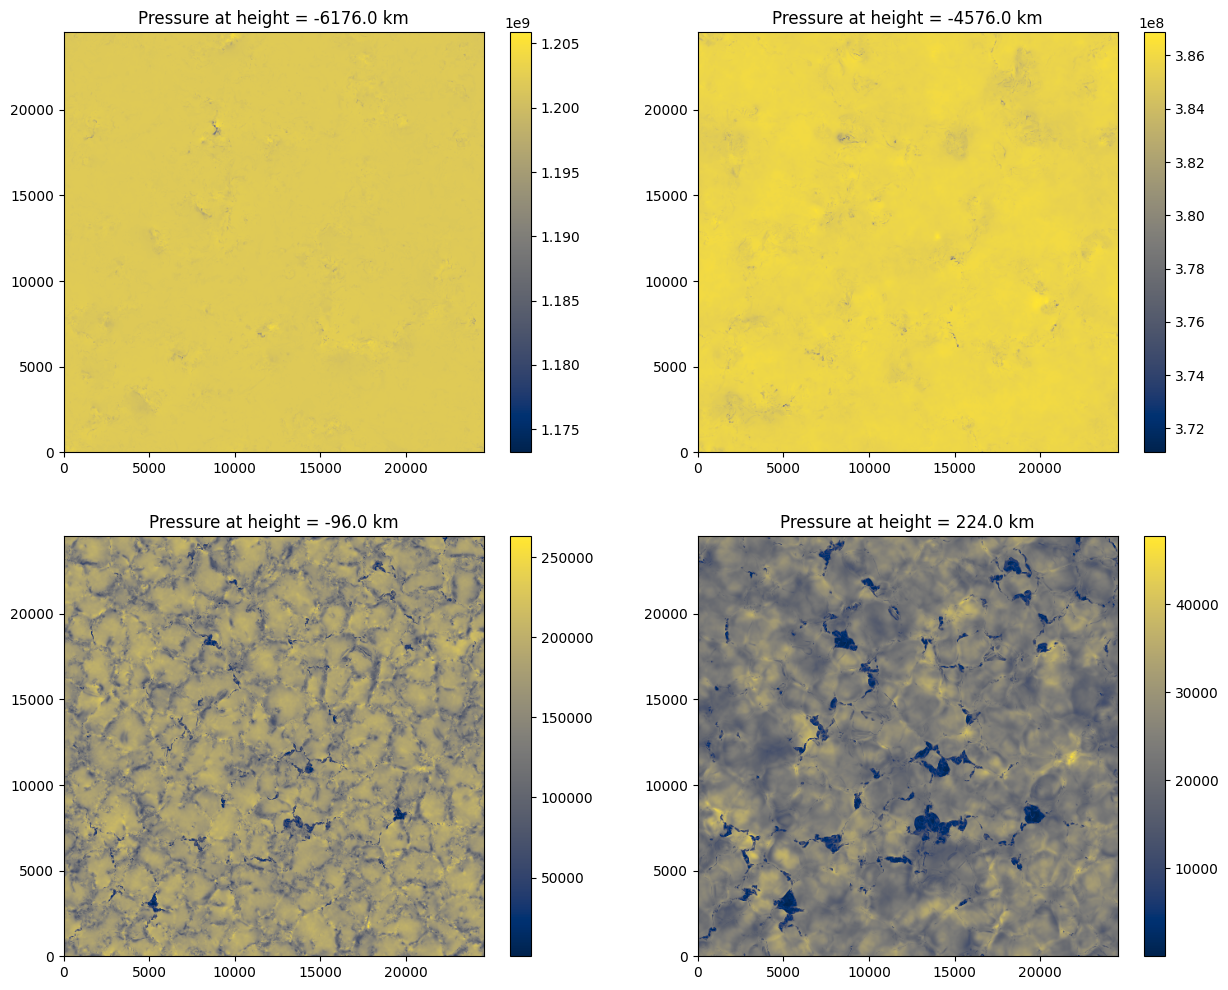

In [14]:
# Pressure

heights = [0, 100, 380, 400]
plt.figure(figsize=[15,12]) 
for i in range(0,4):
    plt.subplot(2,2,i+1)
    plt.imshow(atmos[1,:,:,heights[i]].T, origin='lower', cmap = 'cividis', extent = [x[0],x[-1],y[0],y[-1]])
    plt.title("Pressure at height = "+str(z[heights[i]])+ " km")
    plt.colorbar()

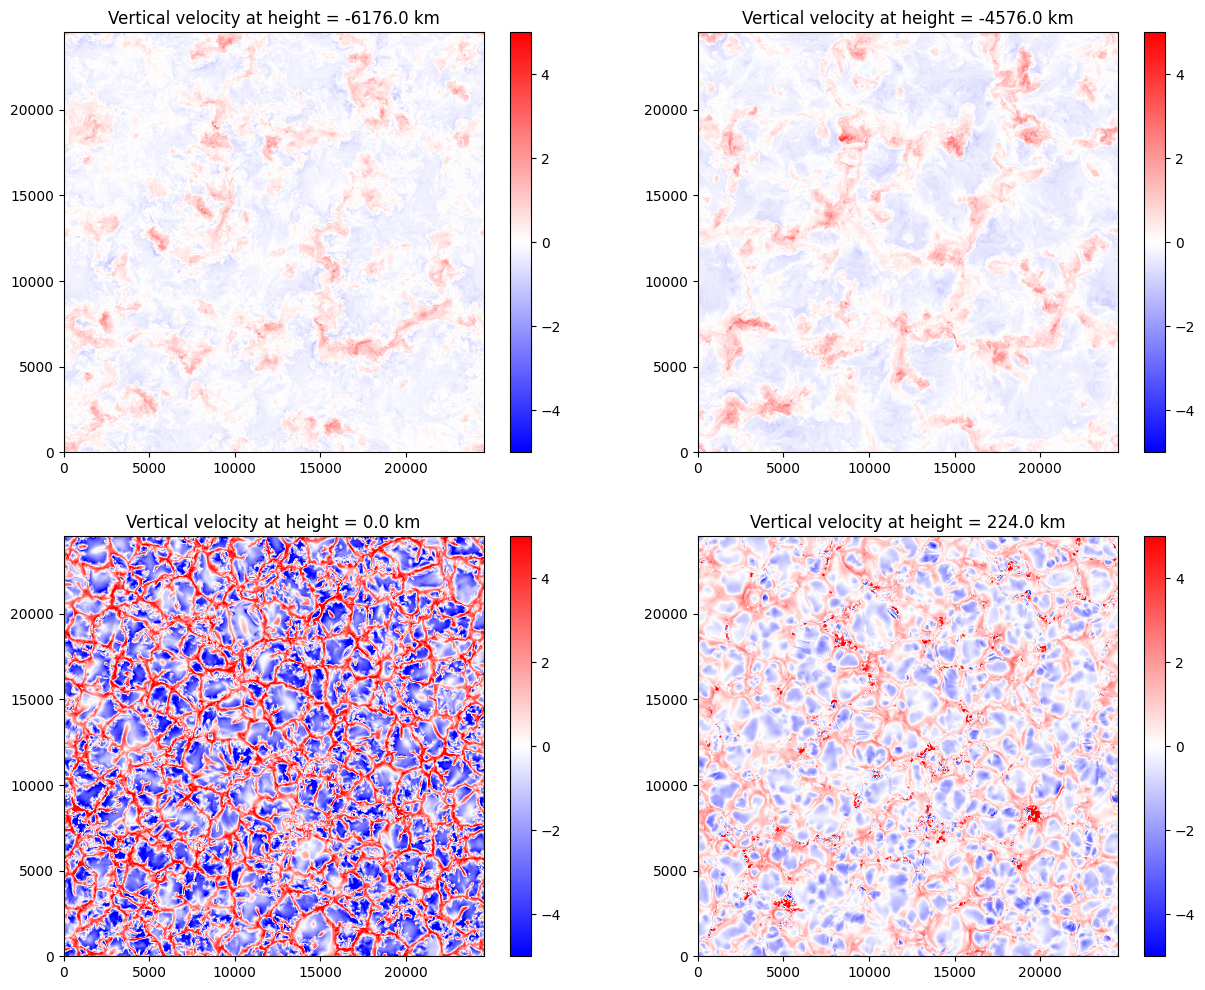

In [15]:
# Vertical velocity

heights = [0, 100, 386, 400]
plt.figure(figsize=[15,12]) 
for i in range(0,4):
    plt.subplot(2,2,i+1)
    plt.imshow(atmos[5,:,:,heights[i]].T/-1E5, origin='lower', cmap = 'bwr', extent = [x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5)
    plt.title("Vertical velocity at height = "+str(z[heights[i]])+ " km")
    plt.colorbar()
plt.savefig("velocities_muram.png")

# Before we continue, we will look at horizontal velocities! 

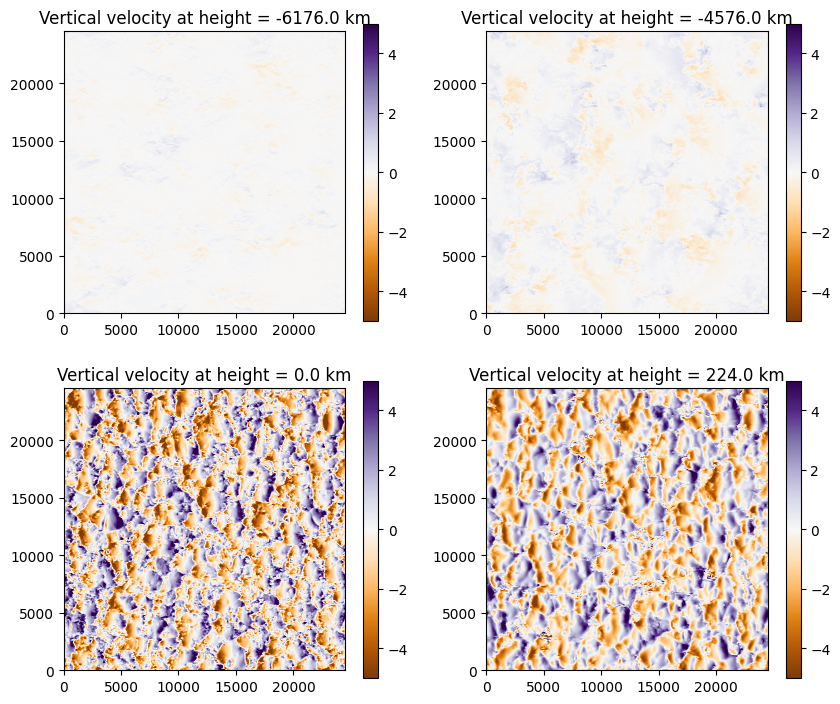

In [17]:
# Horizontal velocity

heights = [0, 100, 386, 400]
plt.figure(figsize=[10,8.5]) 
for i in range(0,4):
    plt.subplot(2,2,i+1)
    plt.imshow(atmos[3,:,:,heights[i]].T/1E5, origin='lower', cmap = 'PuOr', extent = [x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5)
    plt.title("vx velocity at height = "+str(z[heights[i]])+ " km")
    plt.colorbar()
plt.savefig("velocities_muram.png")

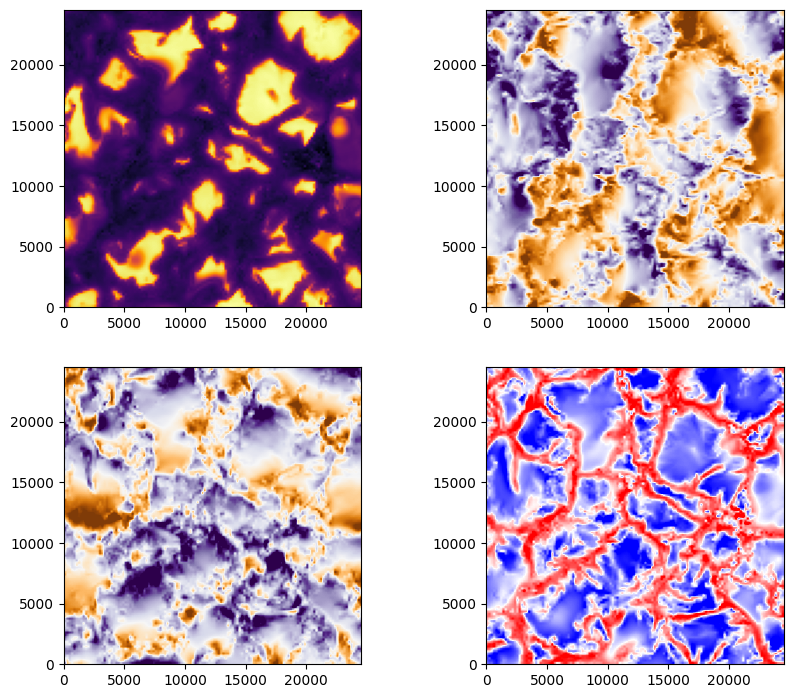

In [19]:
plt.figure(figsize=[10,8.5]) 
plt.subplot(2,2,1)
plt.imshow(atmos[0,:128,:128,386].T, origin='lower', cmap = 'inferno', extent = [x[0],x[-1],y[0],y[-1]])
plt.subplot(2,2,2)
plt.imshow(atmos[3,:128,:128,386].T/1E5, origin='lower', cmap = 'PuOr', extent = [x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5)
plt.subplot(2,2,3)
plt.imshow(atmos[4,:128,:128,386].T/1E5, origin='lower', cmap = 'PuOr', extent = [x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5)
plt.subplot(2,2,4)
plt.imshow(atmos[5,:128,:128,386].T/-1E5, origin='lower', cmap = 'bwr', extent = [x[0],x[-1],y[0],y[-1]],vmin=-5,vmax=5)

#plt.title("Vertical velocity at height = "+str(z[heights[i]])+ " km")

# Continuation: Handson7, 02/07/2025

# First complete #5, estimate where the surface is, comparing effective temperature of each layer to known effective temperature of the Sun 

#### To do that, we will calculate the effective temperature using Stefan Boltzmann law of each layer, and see where it agrees with 5777 K

#### We are going to compare $<\sigma T^4>$ for different $z$-s, with known value for $\sigma T_{\odot}^4$

In [20]:
# This should be fairly quick, note that we don't need specific value for sigma. 
# For completeness:
sigma_sb = 4.67E-8 # W / m^2 / K^4 --> if we wanted to use this we would have to recall that MuRAM units are in cgs

# We can simply compare mean emissive temperature of each layer, defined as: 

T_mean_sb = np.mean(atmos[0,:,:,:] ** 4.0, axis=(0,1)) ** 0.25

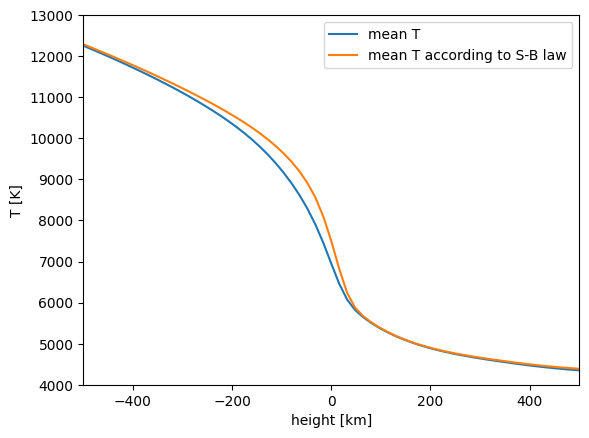

In [25]:
plt.plot(z,mean_atmos[0,:], label='mean T')
plt.plot(z,T_mean_sb, label = 'mean T according to S-B law')
plt.xlabel("height [km]")
plt.ylabel("T [K]")
plt.xlim([-500,500])
plt.ylim([4000,13000])
plt.legend()

## Next tasks: 

## We want to calculate and visualize energy fluxes through the atmosphere. There are 3: 

## 1) Kinetic energy flux: $F_{kin} = \frac{\rho v^2}{2} v_z$

## 2) Enthalpy flux: $ F_{ent} = (\rho v_z - <\rho v_z>_{x,y}) C_P (T-<T>_{x,y}) $

## 3) Radiative flux: $F_{rad} = -{\rm const} \frac{1}{\overline{\kappa}} T^3 \frac{dT}{dz}$

## Useful is to know that $C_P \approx 21 {\rm kJ/kg/K}$, for temperature of 6000 K. 

### To do: 

### 1) Discuss the equations 
### 2) How can we estimate mass densities? 
### 3) Calculate all these quantities, average them over x,y and visualize their variation with height. 
### 4) Calculate the spatial dependence of these quantities for a few representative $z$

### Discussing question 1: 

### Equation for kinetic flux: 

### $\rho v^2 / 2$ is energy density 

### When we multiply it with $v_z$ we get: $[J / m^3] \times m/s = J / m^2 s$ which is a specific flux, or flux surface density. 

### Equation for heat flux: 

